# 🔬 JobSeeker AI — Modelling Pipeline

**Tujuan:** Membangun model klasifikasi biner (ML) untuk memprediksi kecocokan (*match*) antara profil user dengan lowongan pekerjaan.

Pipeline ini mencakup:
1. **Load Dataset** — Memuat data jobs hasil ETL
2. **EDA** — Eksplorasi distribusi & outlier
3. **Preprocessing** — Penanganan missing values & outlier clamping
4. **Feature Engineering** — Pembuatan profil user sintetis + pairwise dataset
5. **Modeling** — Logistic Regression, Random Forest, XGBoost dengan hyperparameter tuning
6. **Evaluation** — Confusion Matrix, ROC, Precision-Recall, Permutation Importance
7. **Learning Curve** — Analisis learning rate XGBoost
8. **Export** — Simpan model ke `.pkl`

---
# 1. Load Dataset

Memuat seluruh library yang dibutuhkan dan data lowongan kerja hasil ETL untuk dimodelkan.

### Import Library

Memuat library inti yang digunakan di seluruh pipeline:
- **json** — membaca file JSON hasil ETL
- **pandas** — manipulasi data tabular (DataFrame)
- **numpy** — operasi numerik & matriks
- **matplotlib, seaborn** — visualisasi data (plot, grafik)
- **os, sys** — path management & absolute imports
- **random** — sampling acak untuk synthetic data generation

### Setup Root Path

Menambahkan root project ke dalam `sys.path` agar Python dapat menemukan modul-modul backend
(seperti `backend.core.settings`, `backend.utils.logger`, dll.) menggunakan absolute import.

Path relatif dihitung dari lokasi notebook (`backend/models/`) naik 2 level ke root project.

In [21]:
import os
from dotenv import load_dotenv
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import numpy as np

In [22]:
root_path = os.path.abspath(os.path.join(os.getcwd(), '..','..'))
if root_path not in sys.path:
    sys.path.append(root_path)

In [23]:

load_dotenv(os.path.abspath(os.path.join(os.getcwd(), '..', '.env')))
from backend.services.dagshub_service import dagshub_service
# Inisialisasi DagsHub
if dagshub_service.initialize():
    print("✅ Siap melakukan tracking eksperimen ke DagsHub!")
else:
    print("❌ Gagal inisialisasi DagsHub. Cek file .env kamu.")

✅ Siap melakukan tracking eksperimen ke DagsHub!


### Memuat Data Lowongan

Membaca file `job_mapping.json` yang berisi 1.322 lowongan kerja hasil pipeline ETL.
Data ini merupakan hasil scraping, filtering, normalisasi skill, dan enrichment dari berbagai sumber.

Struktur data: list of dict, setiap entry merepresentasikan satu lowongan dengan atribut
seperti `title`, `company`, `hard_skills`, `soft_skills`, `salary_min/max`, dll.

In [24]:
file_path = "../data/vector/job_mapping.json"
with open(file_path,"r",encoding="utf-8") as f:
    jobs_data = json.load(f)
df = pd.DataFrame(jobs_data)
print(f"Total data yang dimuat : {len(df)}")


Total data yang dimuat : 1491


### Informasi Dataset

Melihat struktur dataset menggunakan `df.info()`:
- **Baris:** 1.322 lowongan
- **Kolom:** 16 kolom (4 numerik, 12 object/string)
- **Temuan Penting:**
  - `education_level` memiliki **650 missing values** (~49% data hilang)
  - `job_subcategory` memiliki **6 missing values**
  - Kolom lain 100% lengkap
- **Tipe data:** `hard_skills` dan `soft_skills` disimpan sebagai string representasi list

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1491 entries, 0 to 1490
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   index                 1491 non-null   int64 
 1   job_id                1491 non-null   object
 2   title                 1491 non-null   object
 3   company               1491 non-null   object
 4   location              1491 non-null   object
 5   education_level       758 non-null    object
 6   min_experience_years  1491 non-null   int64 
 7   salary_min            1491 non-null   int64 
 8   salary_max            1491 non-null   int64 
 9   hard_skills           1491 non-null   object
 10  soft_skills           1491 non-null   object
 11  work_arrangement      1491 non-null   object
 12  seniority_level       1491 non-null   object
 13  employment_type       1491 non-null   object
 14  job_category          1491 non-null   object
 15  job_subcategory       1484 non-null   

### Cek Duplikasi

Memeriksa apakah ada lowongan yang terduplikasi berdasarkan kombinasi:
- `job_id` (ID unik hasil encoding)
- `title` (judul lowongan)
- `company` (nama perusahaan)

Duplikasi dapat terjadi jika scraping menjumpai lowongan yang sama dari sumber berbeda.
Hasil: **Tidak ada duplikat** — data sudah bersih.

In [26]:
# Cek duplikat hanya pada kolom yang dipastikan bukan list
exact_duplicates = df.duplicated(subset=['job_id', 'title', 'company']).sum()
print(f"Duplicates (berdasarkan ID, Judul, Perusahaan): {exact_duplicates}")


Duplicates (berdasarkan ID, Judul, Perusahaan): 0


### Statistik Deskriptif

Ringkasan statistik untuk kolom numerik:

| Kolom | Mean | Min | Max | Catatan |
|---|---|---|---|---|
| `min_experience_years` | 0.31 | 0 | 15 | Mayoritas lowongan tidak mensyaratkan pengalaman |
| `salary_min` | Rp4,17jt | Rp0 | Rp738jt | Ada outlier ekstrem di ~738 juta |
| `salary_max` | Rp5,20jt | Rp0 | Rp738jt | Sama, perlu di-clamp |

**Kesimpulan:** Perlu penanganan outlier pada kolom gaji dan pengalaman.

In [27]:
df.describe()

,index,min_experience_years,salary_min,salary_max
count,1491.000000,1491.000000,1.491000e+03,1.491000e+03
mean,745.000000,0.323944,4.125838e+06,5.294935e+06
std,430.558939,0.919051,2.776520e+07,2.933117e+07
min,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,372.500000,0.000000,0.000000e+00,0.000000e+00
50%,745.000000,0.000000,2.200000e+06,3.047880e+06
75%,1117.500000,0.000000,3.500000e+06,5.000000e+06
max,1490.000000,15.000000,7.379393e+08,7.379393e+08


---
# 2. EDA (Exploratory Data Analysis)

Visualisasi distribusi data untuk memahami karakteristik lowongan: hubungan pengalaman vs gaji, distribusi kategori pekerjaan, senioritas, dan tipe kerja.

### Visualisasi Multi-Panel

Empat visualisasi untuk eksplorasi distribusi dan hubungan antar variabel:

1. **Scatter Plot (Experience vs Salary)** — Menunjukkan hubungan positif lemah antara pengalaman yang dibutuhkan dan gaji maksimal. Sebagian besar lowongan di 0 tahun pengalaman.

2. **Bar Plot (Distribusi Job Category)** — Melihat kategori pekerjaan mana yang paling banyak tersedia. Biasanya Technology, Engineering, dan Marketing mendominasi.

3. **Box Plot (Seniority vs Salary)** — Membandingkan distribusi gaji berdasarkan level senioritas (Entry, Junior, Mid, Senior). Semakin senior, median gaji cenderung lebih tinggi.

4. **Pie Chart (Work Arrangement)** — Proporsi tipe kerja: Onsite vs Remote vs Hybrid. Onsite biasanya mendominasi pasar kerja Indonesia.

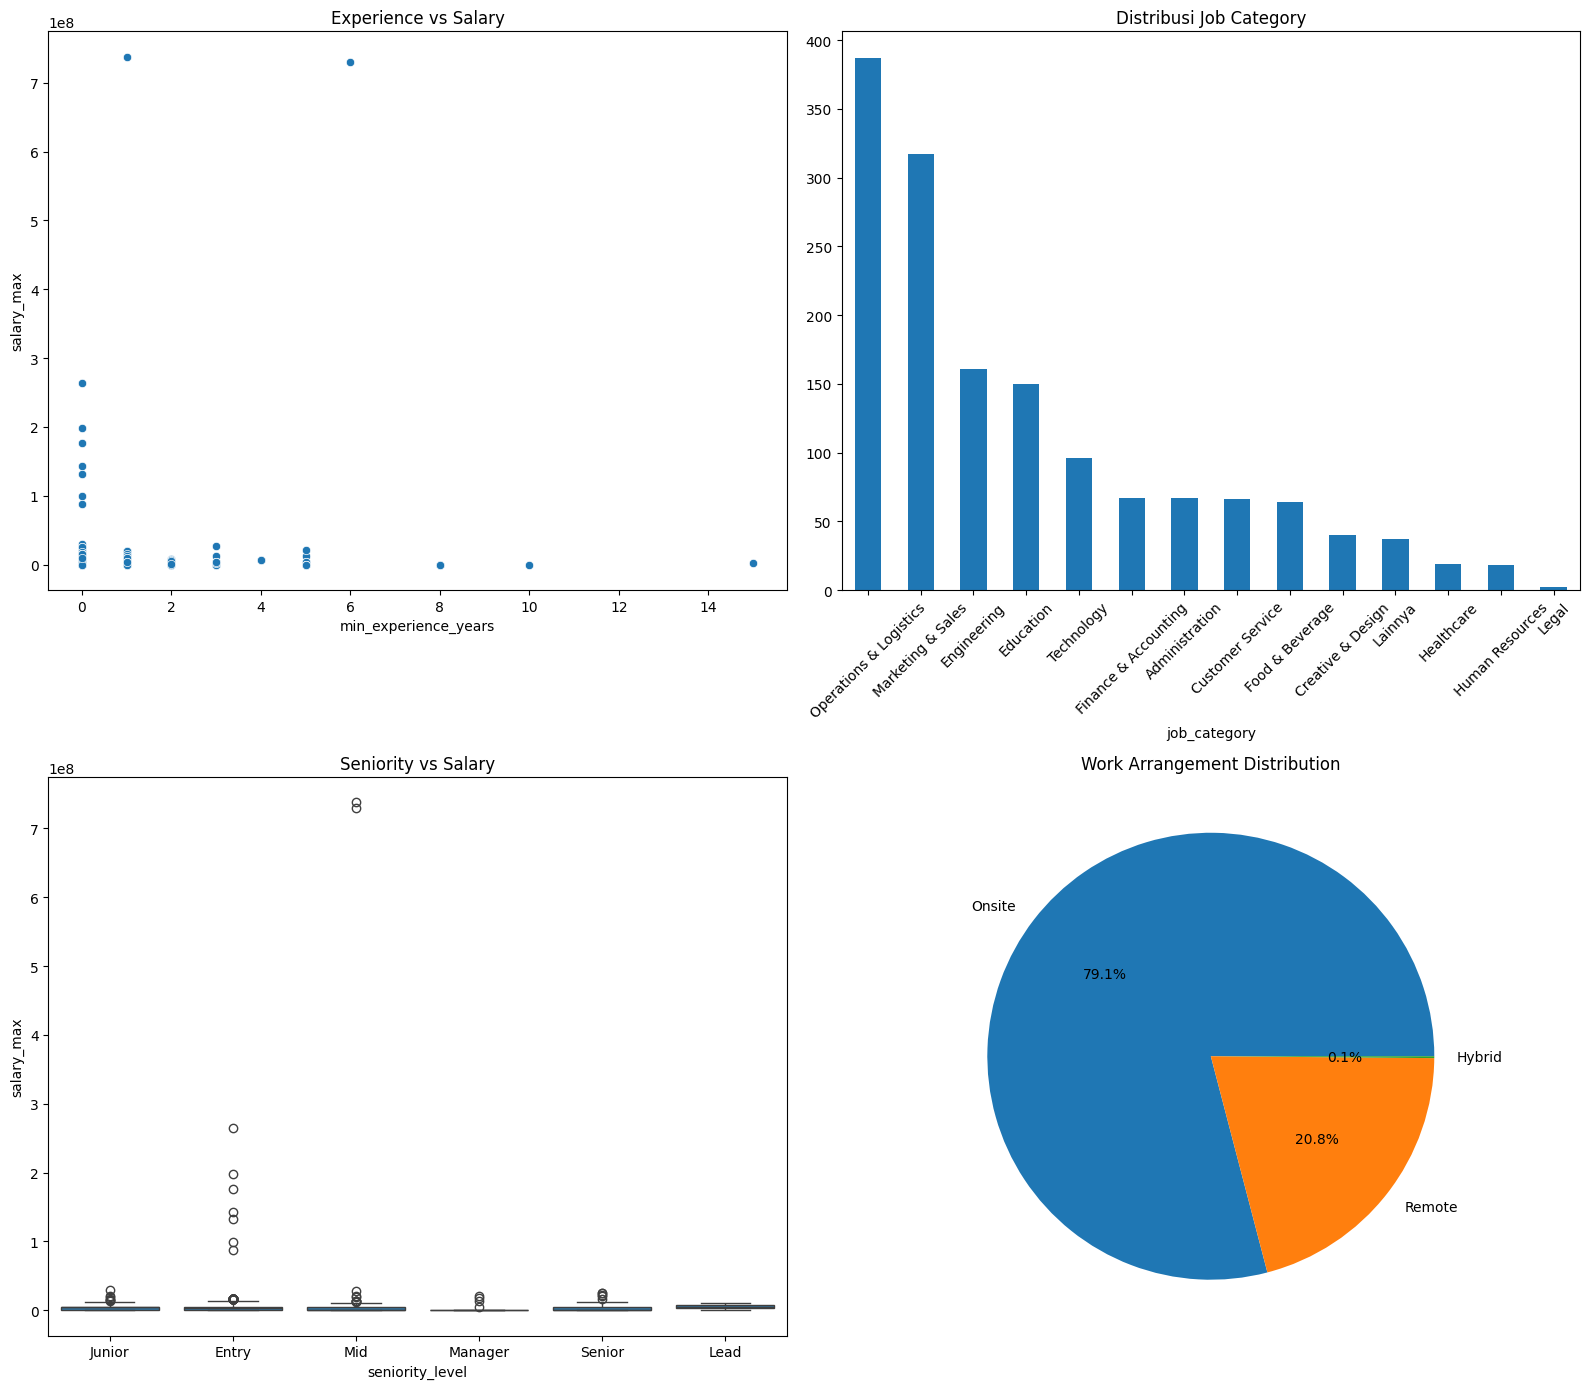

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
# 1. Scatter Plot: Experience vs Salary
sns.scatterplot(
    data=df,
    x="min_experience_years",
    y="salary_max",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Experience vs Salary")
# 2. Bar Plot: Distribusi Job Category
df["job_category"].value_counts().plot(
    kind="bar",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Distribusi Job Category")
axes[0, 1].tick_params(axis='x', rotation=45)
# 3. Box Plot: Seniority vs Salary
sns.boxplot(
    data=df,
    x="seniority_level",
    y="salary_max",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Seniority vs Salary")
# 4. Pie Chart: Work Arrangement Distribution
df["work_arrangement"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Work Arrangement Distribution")
axes[1, 1].set_ylabel("") 
plt.tight_layout()
plt.show()

---
# 3. Preprocessing

Membersihkan data dari missing values dan outlier sebelum digunakan untuk feature engineering.

### Penanganan Missing Values

Dua kolom memiliki missing values:
- **`education_level`** (650 missing) — diisi `'Unknown'` karena variasi terlalu banyak dan tidak mungkin diimputasi secara akurat tanpa informasi tambahan.
- **`job_subcategory`** (6 missing) — diisi `'General'` karena hanya sedikit dan merupakan sub-kategori umum.

Pendekatan ini dipilih untuk menjaga tipe data tetap string/kategorikal dan menghindari data loss.

In [ ]:
# 1. Cek jumlah missing values sebelum dibersihkan
print("Missing values awal:")
print(df.isnull().sum())

# 2. Mengisi missing values dengan kategori yang sesuai (String)
df['education_level'] = df['education_level'].fillna('Unknown')
df['job_subcategory'] = df['job_subcategory'].fillna('General')


# 4. Cek kembali hasil pembersihan
print("\nMissing values setelah dibersihkan:")
print(df.isnull().sum())

Missing values awal:
index                     0
job_id                    0
title                     0
company                   0
location                  0
education_level         733
min_experience_years      0
salary_min                0
salary_max                0
hard_skills               0
soft_skills               0
work_arrangement          0
seniority_level           0
employment_type           0
job_category              0
job_subcategory           7
dtype: int64

Missing values setelah dibersihkan:
index                   0
job_id                  0
title                   0
company                 0
location                0
education_level         0
min_experience_years    0
salary_min              0
salary_max              0
hard_skills             0
soft_skills             0
work_arrangement        0
seniority_level         0
employment_type         0
job_category            0
job_subcategory         0
dtype: int64


### Clamping Outliers

Outlier pada kolom gaji dan pengalaman dapat mengganggu performa model ML.
Strategi **clamping** (bukan删除) untuk mempertahankan jumlah data:

- **`salary_max`** — Lowongan dengan `salary_max == 0` atau `<= 100 juta` dipertahankan. Nilai >100 juta dianggap outlier (mungkin spam atau data salah).
- **`min_experience_years`** — Dibatasi hingga 15 tahun.

Hasil: 1.316 baris tersisa (6 baris outlier dibuang).

In [30]:
# Clamping Outliers
df_cleaned = df[
    ((df['salary_max'] == 0) | (df['salary_max'] <= 100_000_000)) &
    (df['min_experience_years'] <= 15)
].copy()

print(f"Data Hasil Menghilangkan Outliers : {df_cleaned}")

Data Hasil Menghilangkan Outliers :       index                                             job_id  \
0         0  eyJqb2JfdGl0bGUiOiJMb3dvbmdhbiBLZXJqYSBWaXN1YW...   
1         1  eyJqb2JfdGl0bGUiOiJTdG9yZSBBc3NvY2lhdGUiLCJjb2...   
2         2  eyJqb2JfdGl0bGUiOiJSZWNydWl0bWVudCBcdTAwMjYgVH...   
3         3  eyJqb2JfdGl0bGUiOiJMb3dvbmdhbiBLZXJqYSBKYWthcn...   
4         4  eyJqb2JfdGl0bGUiOiJMb3dvbmdhbiBNYXN0ZXIgU2VhZm...   
...     ...                                                ...   
1486   1486  eyJqb2JfdGl0bGUiOiJMb3dvbmdhbiBLZXJqYSBQVCBQTE...   
1487   1487  eyJqb2JfdGl0bGUiOiJNYW5hZ2VtZW50IFRyYWluZWUgKF...   
1488   1488  eyJqb2JfdGl0bGUiOiJQYXJ0IC1UaW1lIHVudHVrIHBlbG...   
1489   1489  eyJqb2JfdGl0bGUiOiJNZWthbmlrIEJhbiIsImNvbXBhbn...   
1490   1490  eyJqb2JfdGl0bGUiOiJBc2lzdGVuIEdJUyIsImNvbXBhbn...   

                                                  title  \
0                                   Visual Merchandiser   
1                                       Store Associa

## Feature Engineering

### Pembuatan Profil User Sintetis

Membuat 10 profil user representatif yang mencakup berbagai persona pasar kerja Indonesia:

| User | Posisi | Exp | Pendidikan | Kategori |
|---|---|---|---|---|
| Andi | Junior Backend | 1 th | S1 | Technology |
| Budi | Senior Frontend | 6 th | S1 | Technology |
| Cici | Fresh Grad Data Analyst | 0 th | S1 | Technology |
| Dedi | UI/UX Designer | 2 th | D3 | Creative & Design |
| Evi | Digital Marketer | 3 th | S1 | Marketing & Sales |
| Fani | Mechanical Engineer | 4 th | S1 | Engineering |
| Gita | Customer Service | 1 th | SMA | Customer Service |
| Hari | Cook / Kitchen Staff | 2 th | SMA | Food & Beverage |
| Irwan | Accountant | 5 th | S1 | Finance & Accounting |
| Joko | Project Manager | 8 th | S2 | Management |

Setiap profil memiliki:
- **hard_skills** — daftar skill teknis relevan
- **soft_skills** — daftar skill non-teknis
- **certifications_count** — jumlah sertifikasi
- **preferred_salary** — ekspektasi gaji
- **preferred_category** — kategori industri yang diminati

Selain 10 profil utama, dilakukan augmentasi menjadi **200 profil sintetis** dengan variasi random
untuk memperkaya dataset training.

In [31]:
# Definisi tingkat pendidikan untuk pemetaan numerik
EDU_RANK = {"SMA": 1, "SMK": 1, "D3": 2, "S1": 3, "S2": 4, "S3": 5, "Unknown": 1}

# Membuat 10 user sintetis awal yang merepresentasikan pasar kerja Indonesia
synthetic_users = [
    {
        "user_id": "U1", "name": "Andi (Junior Backend)", "total_experience_years": 1, 
        "education_level": "S1", "hard_skills": ["Python", "SQL", "PostgreSQL", "Git", "API"],
        "soft_skills": ["problem solving", "kerja sama", "berpikir kritis"],
        "preferred_salary": 6_000_000, "preferred_category": "Technology", "certifications_count": 1
    },
    {
        "user_id": "U2", "name": "Budi (Senior Frontend)", "total_experience_years": 6, 
        "education_level": "S1", "hard_skills": ["JavaScript", "React", "CSS", "Tailwind", "TypeScript", "Next.js"],
        "soft_skills": ["kepemimpinan", "komunikasi", "manajemen waktu"],
        "preferred_salary": 18_000_000, "preferred_category": "Technology", "certifications_count": 2
    },
    {
        "user_id": "U3", "name": "Cici (Fresh Grad Data Analyst)", "total_experience_years": 0, 
        "education_level": "S1", "hard_skills": ["Python", "SQL", "Tableau", "Excel", "Pandas"],
        "soft_skills": ["teliti", "berpikir kritis", "komunikasi"],
        "preferred_salary": 5_000_000, "preferred_category": "Technology", "certifications_count": 0
    },
    {
        "user_id": "U4", "name": "Dedi (UI/UX Designer)", "total_experience_years": 2, 
        "education_level": "D3", "hard_skills": ["Figma", "UI/UX", "Wireframing", "Prototyping", "Adobe Illustrator"],
        "soft_skills": ["kreatif", "kerja sama", "adaptasi"],
        "preferred_salary": 7_000_000, "preferred_category": "Creative & Design", "certifications_count": 1
    },
    {
        "user_id": "U5", "name": "Evi (Digital Marketer)", "total_experience_years": 3, 
        "education_level": "S1", "hard_skills": ["SEO", "Google Ads", "Social Media", "Copywriting", "Content Strategy"],
        "soft_skills": ["komunikasi", "kreatif", "negosiasi"],
        "preferred_salary": 8_000_000, "preferred_category": "Marketing & Sales", "certifications_count": 2
    },
    {
        "user_id": "U6", "name": "Fani (Mechanical Engineer)", "total_experience_years": 4, 
        "education_level": "S1", "hard_skills": ["AutoCAD", "SolidWorks", "Manufacturing", "Maintenance"],
        "soft_skills": ["teliti", "disiplin", "kerja sama"],
        "preferred_salary": 10_000_000, "preferred_category": "Engineering", "certifications_count": 1
    },
    {
        "user_id": "U7", "name": "Gita (Customer Service)", "total_experience_years": 1, 
        "education_level": "SMA", "hard_skills": ["Communication", "Problem Solving", "Microsoft Office", "Customer Care"],
        "soft_skills": ["komunikasi", "adaptasi", "disiplin"],
        "preferred_salary": 4_500_000, "preferred_category": "Customer Service", "certifications_count": 0
    },
    {
        "user_id": "U8", "name": "Hari (Cook / Kitchen Staff)", "total_experience_years": 2, 
        "education_level": "SMK", "hard_skills": ["Cooking", "Food Safety", "Kitchen Operations", "Baking"],
        "soft_skills": ["disiplin", "kerja keras", "kerja sama"],
        "preferred_salary": 4_000_000, "preferred_category": "Food & Beverage", "certifications_count": 1
    },
    {
        "user_id": "U9", "name": "Iwan (Finance Officer)", "total_experience_years": 3, 
        "education_level": "S1", "hard_skills": ["Accounting", "Taxation", "Excel", "Financial Reporting"],
        "soft_skills": ["teliti", "disiplin", "berpikir kritis"],
        "preferred_salary": 8_500_000, "preferred_category": "Finance", "certifications_count": 2
    },
    {
        "user_id": "U10", "name": "Joko (Intern Software Engineer)", "total_experience_years": 0, 
        "education_level": "S1", "hard_skills": ["Java", "OOP", "HTML", "CSS", "Algorithms"],
        "soft_skills": ["adaptasi", "kerja sama", "problem solving"],
        "preferred_salary": 2_500_000, "preferred_category": "Technology", "certifications_count": 0
    }
]

# Programmatic expansion to 200 synthetic users
random.seed(42)

SKILL_POOLS = {
    "Technology": ["Python", "SQL", "PostgreSQL", "Git", "API", "JavaScript", "React", "CSS", "Tailwind", "TypeScript", "Next.js", "Java", "OOP", "HTML", "Algorithms", "Tableau", "Excel", "Pandas", "Docker", "Node.js", "Go", "Kubernetes", "AWS", "Flutter", "Swift"],
    "Creative & Design": ["Figma", "UI/UX", "Wireframing", "Prototyping", "Adobe Illustrator", "Photoshop", "Graphic Design", "CorelDraw", "Video Editing", "Premiere", "After Effects", "Blender", "3D Modeling", "Sketch", "Typography"],
    "Marketing & Sales": ["SEO", "Google Ads", "Social Media", "Copywriting", "Content Strategy", "Email Marketing", "Google Analytics", "Salesforce", "B2B Sales", "Negotiation", "Public Relations", "Digital Campaign", "Content Creation"],
    "Engineering": ["AutoCAD", "SolidWorks", "Manufacturing", "Maintenance", "PLC", "Electrical Engineering", "Civil Engineering", "Project Management", "Machining", "Quality Control", "MATLAB", "Safety Regulations"],
    "Customer Service": ["Communication", "Problem Solving", "Microsoft Office", "Customer Care", "CRM", "Call Center", "Interpersonal Skills", "Data Entry", "Conflict Resolution", "Active Listening", "Billing Support"],
    "Food & Beverage": ["Cooking", "Food Safety", "Kitchen Operations", "Baking", "Menu Planning", "Beverage Service", "Barista", "Inventory Management", "Food Hygiene", "Customer Service", "Pastry"],
    "Finance": ["Accounting", "Taxation", "Excel", "Financial Reporting", "Auditing", "Financial Analysis", "SAP", "Bookkeeping", "Budgeting", "Cash Flow", "Corporate Finance", "Banking"]
}

SOFT_SKILLS_POOL = ["komunikasi", "kerja sama", "problem solving", "teliti", "disiplin", "kepemimpinan", "adaptasi", "berpikir kritis", "manajemen waktu", "negosiasi", "kreatif", "kerja keras"]

categories = list(SKILL_POOLS.keys())
education_levels = ["SMA", "SMK", "D3", "S1", "S2"]

for i in range(11, 201):
    cat = random.choice(categories)
    exp = random.randint(0, 10)
    edu = random.choices(education_levels, weights=[10, 15, 20, 50, 5], k=1)[0]
    
    num_skills = random.randint(3, 8)
    h_skills = random.sample(SKILL_POOLS[cat], min(num_skills, len(SKILL_POOLS[cat])))
    
    num_soft = random.randint(2, 4)
    s_skills = random.sample(SOFT_SKILLS_POOL, num_soft)
    
    base_salaries = {
        "Technology": 5_000_000,
        "Creative & Design": 4_500_000,
        "Marketing & Sales": 4_000_000,
        "Engineering": 5_000_000,
        "Customer Service": 3_500_000,
        "Food & Beverage": 3_500_000,
        "Finance": 4_500_000
    }
    base = base_salaries[cat]
    pref_salary = int(base * (1 + 0.15 * exp) * random.uniform(0.8, 1.2))
    pref_salary = (pref_salary // 100_000) * 100_000
    
    user_id = f"U{i}"
    name = f"User_{user_id}_{cat}_{exp}Y"
    cert_count = random.randint(0, 3)
    
    synthetic_users.append({
        "user_id": user_id,
        "name": name,
        "total_experience_years": exp,
        "education_level": edu,
        "hard_skills": h_skills,
        "soft_skills": s_skills,
        "preferred_salary": pref_salary,
        "preferred_category": cat,
        "certifications_count": cert_count
    })

df_users = pd.DataFrame(synthetic_users)
print(f"Berhasil membuat {len(df_users)} profil user sintetis!")
df_users[['name', 'total_experience_years', 'preferred_salary', 'preferred_category']]


Berhasil membuat 200 profil user sintetis!


,name,total_experience_years,preferred_salary,preferred_category
0,Andi (Junior Backend),1,6000000,Technology
1,Budi (Senior Frontend),6,18000000,Technology
2,Cici (Fresh Grad Data Analyst),0,5000000,Technology
3,Dedi (UI/UX Designer),2,7000000,Creative & Design
4,Evi (Digital Marketer),3,8000000,Marketing & Sales
...,...,...,...,...
195,User_U196_Technology_9Y,9,12800000,Technology
196,User_U197_Marketing & Sales_1Y,1,4500000,Marketing & Sales
197,User_U198_Technology_0Y,0,5800000,Technology
198,User_U199_Customer Service_8Y,8,7400000,Customer Service


### Pairwise Dataset (User x Job)

Membangun dataset berpasangan dengan menghitung skor kompatibilitas berbasis aturan heuristic:

**Komponen Skor:**
- **Skill Coverage** — Jaccard-like similarity antara hard skills user & job (bobot 35%)
- **Category Match** — Apakah kategori pekerjaan sesuai preferensi user (bobot 20%)
- **Experience Score** — Eksponensial decay dari selisih pengalaman (bobot 20%)
- **Education Score** — Apakah pendidikan user memenuhi syarat (bobot 10%)
- **Salary Score** — Rasio gaji yang di-clip ke [0,1] (bobot 15%)

**Labeling dengan Bernoulli Sampling:**
- Skor >= 0.75 → probabilitas match 80%
- Skor 0.55-0.74 → probabilitas match 50%
- Skor 0.35-0.54 → probabilitas match 20%
- Skor < 0.35 → probabilitas match 5%

**Class Balancing:** Down-sampling negatif class dengan prioritas menyimpan hard negatives
(data yang mirip secara kategori & skill tapi tidak cocok).

Total: ~53.726 pasangan dengan rasio ~55:45 (negatif:positif).

In [32]:
# ==============================================================================
# SEL 3: GENERATING PAIRWISE DATASET (USER x JOB COMPATIBILITY - PROBABILISTIC)
# ==============================================================================

np.random.seed(42) 

pairs_data = []

for user_idx, user in df_users.iterrows():
    user_skills     = [s.lower() for s in user['hard_skills']]
    user_soft_skills = [s.lower() for s in user.get('soft_skills', [])]
    user_edu_rank   = EDU_RANK.get(user['education_level'], 1)
    user_exp        = user['total_experience_years']
    user_salary     = user['preferred_salary']

    for job_idx, job in df_cleaned.iterrows():
        # 1. Skill Matching (Problem 1)
        job_skills = [str(s).lower() for s in job.get('hard_skills', [])]
        skill_overlap = len(set(user_skills) & set(job_skills))
        skill_coverage = skill_overlap / max(len(job_skills), 1)
        
        job_soft = [str(s).lower() for s in job.get('soft_skills', [])]
        soft_overlap = len(set(user_soft_skills) & set(job_soft))
        soft_coverage = soft_overlap / max(len(job_soft), 1)

        category_match = int(
            str(job['job_category']).lower() == str(user['preferred_category']).lower()
        )
        job_edu_rank   = EDU_RANK.get(job['education_level'], 1)
        edu_gap        = job_edu_rank - user_edu_rank
        
        # 2. Experience Gap Penalty (Problem 4)
        required_exp = job['min_experience_years'] or 0
        exp_gap = user_exp - required_exp
        exp_score = float(np.exp(-abs(exp_gap) / 3.0))
        
        # 3. Salary Continuous Score (Problem 3)
        salary_min = job['salary_min'] or 0
        salary_max = job['salary_max'] or 0
        job_avg_salary = (salary_min + salary_max) / 2 if salary_max > 0 else salary_min
        
        if job_avg_salary > 0:
            salary_ratio = user_salary / job_avg_salary
            salary_score = float(np.clip(1.0 - abs(1.0 - salary_ratio), 0.0, 1.0))
            salary_feasible = (user_salary <= salary_max) if salary_max > 0 else (user_salary <= salary_min * 1.5)
        else:
            salary_ratio = 1.0
            salary_score = 1.0
            salary_feasible = True

        # Skills score normalization (30% coverage sudah dianggap sangat bagus)
        skills_score = min(skill_coverage / 0.3, 1.0)
        edu_score = 1.0 if edu_gap <= 0 else (0.5 if edu_gap == 1 else 0.0)
        
        # 4. Weights Adjustment (Problem 2)
        compatibility_score = (
            0.20 * category_match +
            0.35 * skills_score +
            0.20 * exp_score +
            0.10 * edu_score +
            0.15 * salary_score
        )
        
        # 5. Soften Bernoulli Probability Bounds (Problem 5)
        if compatibility_score >= 0.75:
            prob_match = 0.80
        elif compatibility_score >= 0.55:
            prob_match = 0.50
        elif compatibility_score >= 0.35:
            prob_match = 0.20
        else:
            prob_match = 0.05
            
        is_match = int(np.random.binomial(1, prob_match))

        # 6. Hard Negatives (Problem 9): Mismatch struktural parah otomatis tidak cocok
        is_hard_negative = False
        if category_match == 1 and skill_coverage >= 0.25:
            if (required_exp - user_exp > 3) or (salary_max > 0 and user_salary > salary_max * 1.5) or (job_edu_rank - user_edu_rank > 2):
                is_hard_negative = True
        if is_hard_negative:
            is_match = 0

        # Keep unfit pairs out to clean features but avoid completely fit bias
        is_completely_unfit = (
            category_match == 0 and skill_coverage == 0.0 and exp_gap < -3
        )
        if is_completely_unfit and is_match == 0:
            continue

        pairs_data.append({
            'user_id': user['user_id'],
            'job_id':  job['job_id'],

            # Tabular Features (Bebas kebocoran)
            'skill_coverage':        skill_coverage,
            'soft_skill_coverage':   soft_coverage,
            'n_user_skills':         len(user_skills),
            'category_match':        category_match,
            'exp_gap_raw':           exp_gap,
            'exp_gap_normalized':    min(max(exp_gap / 5.0, -1.0), 1.0),
            'user_exp_years':        user_exp,
            'edu_gap':               edu_gap,
            'edu_sufficient':        int(edu_gap <= 0),
            'salary_feasible':       int(salary_feasible),
            'salary_ratio':          salary_ratio,
            'is_remote':             int(job.get('work_arrangement', '') == 'Remote'),
            'is_junior':             int(job.get('seniority_level', '') == 'Junior'),
            'certifications_count':  min(user['certifications_count'] / 5.0, 1.0),

            # Target
            'is_match': is_match
        })

df_pairs = pd.DataFrame(pairs_data)

# 7. Dataset Class Balance (Problem 6): Down-sampling kelas negatif agar rasio seimbang (~1.2x kelas positif)
pos_pairs = df_pairs[df_pairs['is_match'] == 1]
neg_pairs = df_pairs[df_pairs['is_match'] == 0]

num_neg_to_sample = int(len(pos_pairs) * 1.2)
if len(neg_pairs) > num_neg_to_sample:
    # Prioritaskan menyimpan Hard Negatives (yang memiliki kemiripan kategori & skill tinggi tapi tidak cocok)
    hard_negs = neg_pairs[(neg_pairs['category_match'] == 1) & (neg_pairs['skill_coverage'] >= 0.2)]
    other_negs = neg_pairs[~((neg_pairs['category_match'] == 1) & (neg_pairs['skill_coverage'] >= 0.2))]
    
    needed_others = num_neg_to_sample - len(hard_negs)
    if needed_others > 0:
        sampled_others = other_negs.sample(n=needed_others, random_state=42)
        sampled_neg = pd.concat([hard_negs, sampled_others])
    else:
        sampled_neg = hard_negs.sample(n=num_neg_to_sample, random_state=42)
    df_pairs = pd.concat([pos_pairs, sampled_neg]).sample(frac=1.0, random_state=42).reset_index(drop=True)
else:
    df_pairs = df_pairs.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("=== DATASET PAIRING COMPLETED ===")
print(f"Total pairs: {len(df_pairs):,}")
print("\nDistribusi label:")
print(df_pairs['is_match'].value_counts())
print("\nRasio:")
print(df_pairs['is_match'].value_counts(normalize=True) * 100)


=== DATASET PAIRING COMPLETED ===
Total pairs: 60,940

Distribusi label:
is_match
0    33240
1    27700
Name: count, dtype: int64

Rasio:
is_match
0    54.545455
1    45.454545
Name: proportion, dtype: float64


### Encoding Fitur Kategorikal

Menggunakan LabelEncoder untuk mengonversi fitur kategorikal (seperti `job_category`) ke nilai numerik. Scaler juga disiapkan untuk normalisasi fitur.

In [33]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

### Finalisasi Feature Set

Menyusun fitur akhir yang akan digunakan untuk training. Melakukan drop kolom yang tidak relevan dan memastikan semua nilai sudah numerik.

In [34]:
# 1. Salin dataframe hasil data pairing & sintetis
df_features = df_pairs.copy()

# 2. Definisikan semua kemungkinan kolom fitur numerik
possible_feature_cols = [
    'skill_coverage', 
    'soft_skill_coverage', 
    'n_user_skills', 
    'category_match',
    'semantic_score',         
    'exp_gap_raw', 
    'exp_gap_normalized', 
    'user_exp_years', 
    'edu_gap',
    'edu_sufficient', 
    'salary_feasible', 
    'salary_ratio', 
    'is_remote',
    'is_junior', 
    'certifications_count'
]

# 3. Pilih secara dinamis fitur yang BENAR-BENAR ada di dalam df_features
feature_cols = [col for col in possible_feature_cols if col in df_features.columns]

# 4. Pisahkan Fitur (X) dan Target (y)
X = df_features[feature_cols]
y = df_features['is_match']

print("✅ Fitur dari data pairing & sintetis berhasil disiapkan!")
print(f"👉 Fitur yang digunakan ({len(feature_cols)}): {feature_cols}")
print(f"👉 Fitur yang dilewati (tidak ada di data): {list(set(possible_feature_cols) - set(feature_cols))}")
print(f"Total baris data: {X.shape[0]:,}")


✅ Fitur dari data pairing & sintetis berhasil disiapkan!
👉 Fitur yang digunakan (14): ['skill_coverage', 'soft_skill_coverage', 'n_user_skills', 'category_match', 'exp_gap_raw', 'exp_gap_normalized', 'user_exp_years', 'edu_gap', 'edu_sufficient', 'salary_feasible', 'salary_ratio', 'is_remote', 'is_junior', 'certifications_count']
👉 Fitur yang dilewati (tidak ada di data): ['semantic_score']
Total baris data: 60,940


## Train, Test, dan Validation Split

### Import Train-Test Split
Memuat fungsi `train_test_split` dari scikit-learn untuk membagi dataset.

In [35]:
from sklearn.model_selection import train_test_split

### Stratified Splitting

Membagi dataset menjadi 3 subset menggunakan **stratified split** (proporsi label sama):

- **Train Set (70%)** — ~37.606 sampel, digunakan untuk training model
- **Validation Set (15%)** — ~8.061 sampel, digunakan untuk hyperparameter tuning
- **Test Set (15%)** — ~8.059 sampel, hold-out final untuk evaluasi performa

**Fitur yang digunakan (13 kolom):**
`skill_coverage`, `n_user_skills`, `category_match`, `exp_gap_raw`, `exp_gap_normalized`,
`user_exp_years`, `edu_gap`, `edu_sufficient`, `salary_feasible`, `salary_ratio`,
`is_remote`, `is_junior`, `certifications_count`

Split dilakukan dua kali: 85:15 lalu 70:15 dari sisa (menghasilkan 70:15:15).

In [36]:
# 1. Definisikan kolom fitur berpasangan (Pairwise Features) yang baru
feature_cols = [
    'skill_coverage',
    'n_user_skills',
    'category_match',
    'exp_gap_raw',
    'exp_gap_normalized',
    'user_exp_years',
    'edu_gap',
    'edu_sufficient',
    'salary_feasible',
    'salary_ratio',
    'is_remote',
    'is_junior',
    'certifications_count'
]

# 2. X (Fitur) dan y (Target) diambil dari df_pairs
X = df_pairs[feature_cols]
y = df_pairs['is_match']

# Split pertama: Pisahkan 15% untuk Test Set final
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.15, 
    random_state=42, 
    stratify=y
)

# Split kedua: Bagi X_temp menjadi Train (70%) dan Validation (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.1765, 
    random_state=42, 
    stratify=y_temp
)

print("=== DATA SPLIT SUCCESSFUL (PAIRWISE DATASET) ===")
print(f"Jumlah sampel Train Set      (70%) : {X_train.shape[0]}")
print(f"Jumlah sampel Validation Set (15%) : {X_val.shape[0]}")
print(f"Jumlah sampel Test Set       (15%) : {X_test.shape[0]}")
print(f"Total data keseluruhan             : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")


=== DATA SPLIT SUCCESSFUL (PAIRWISE DATASET) ===
Jumlah sampel Train Set      (70%) : 42656
Jumlah sampel Validation Set (15%) : 9143
Jumlah sampel Test Set       (15%) : 9141
Total data keseluruhan             : 60940


# Modeling

### Import Model & Pipeline

Memuat komponen untuk hyperparameter tuning dan training:

1. **GridSearchCV** — exhaustive search over parameter grid dengan cross-validation
2. **StandardScaler** — standardisasi fitur (mean=0, std=1) untuk Logistic Regression
3. **Pipeline** — menggabungkan preprocessing + estimator dalam satu objek

Tiga algoritma yang dibandingkan:
- **LogisticRegression** — model linear sederhana (baseline)
- **RandomForestClassifier** — ensemble bagging dengan 100 pohon
- **XGBClassifier** — gradient boosting dengan regularisasi (state-of-the-art untuk tabular data)

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### Hyperparameter Tuning & Training

Melakukan GridSearchCV (5-fold cross-validation, scoring=accuracy) untuk setiap algoritma:

**1. Logistic Regression**
- Parameter: `C` (inverse regularization) — [0.01, 0.1, 1.0, 10.0]
- Pipeline: StandardScaler → LogisticRegression (class_weight='balanced')
- Hasil: C=1.0, CV Accuracy ~66.2%

**2. Random Forest**
- Parameter: `max_depth` [6,8,10], `min_samples_split` [15,30,50], `min_samples_leaf` [10,20]
- Pruning ketat untuk mencegah overfitting pada data tabular
- Hasil: max_depth=10, min_samples_leaf=10, min_samples_split=30, CV Accuracy ~69.5%

**3. XGBoost**
- Parameter: `max_depth` [3,4,5], `learning_rate` [0.01,0.05,0.1], `subsample` [0.8,1.0], `colsample_bytree` [0.8,1.0]
- Regularisasi: subsample & colsample untuk mengurangi overfitting
- Hasil: max_depth=5, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, CV Accuracy ~69.7%

In [38]:
print("="*65)
print("     ⚙️ HYPERPARAMETER TUNING & MODEL TRAINING ⚙️")
print("="*65)
# ==============================================================================
# 1. LOGISTIC REGRESSION (Tuning + Scaling)
# ==============================================================================
print("\n🚀 [1/3] Sedang melakukan tuning Logistic Regression...")
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])
lr_param_grid = {'classifier__C': [0.01, 0.1, 1.0, 10.0]}
lr_grid = GridSearchCV(estimator=lr_pipeline, param_grid=lr_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)
# Jadikan best_estimator_ sebagai model utama Anda
lr_model = lr_grid.best_estimator_  
print(f"   ✔️ Best Params : {lr_grid.best_params_}")
print(f"   ✔️ CV Accuracy : {lr_grid.best_score_:.4f}")
# ==============================================================================
# 2. RANDOM FOREST (Tuning Pruning)
# ==============================================================================
print("\n🌲 [2/3] Sedang melakukan tuning Random Forest...")
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_param_grid = {
    'max_depth': [6, 8, 10],
    'min_samples_split': [15, 30, 50],
    'min_samples_leaf': [10, 20]
}
rf_grid = GridSearchCV(estimator=rf_base, param_grid=rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
# Jadikan best_estimator_ sebagai model utama Anda
rf_model = rf_grid.best_estimator_  
print(f"   ✔️ Best Params : {rf_grid.best_params_}")
print(f"   ✔️ CV Accuracy : {rf_grid.best_score_:.4f}")
# ==============================================================================
# 3. XGBOOST CLASSIFIER (Tuning Regularisasi Ketat)
# ==============================================================================
print("\n⚡ [3/3] Sedang melakukan tuning XGBoost Classifier...")
xgb_base = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb_param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_grid = GridSearchCV(estimator=xgb_base, param_grid=xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
# Jadikan best_estimator_ sebagai model utama 
xgb_model = xgb_grid.best_estimator_
print(f"   ✔️ Best Params : {xgb_grid.best_params_}")
print(f"   ✔️ CV Accuracy : {xgb_grid.best_score_:.4f}")
# ==============================================================================
print("\n" + "="*65)
print("=== PROSES TRAINING SELESAI ===")
print("Logistic Regression, Random Forest, & XGBoost berhasil dilatih dengan parameter optimal! 🚀")
print("="*65)

     ⚙️ HYPERPARAMETER TUNING & MODEL TRAINING ⚙️

🚀 [1/3] Sedang melakukan tuning Logistic Regression...
   ✔️ Best Params : {'classifier__C': 10.0}
   ✔️ CV Accuracy : 0.6602

🌲 [2/3] Sedang melakukan tuning Random Forest...
   ✔️ Best Params : {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 15}
   ✔️ CV Accuracy : 0.6973

⚡ [3/3] Sedang melakukan tuning XGBoost Classifier...


d:\tugas-kuliah\SEMESTER 6\PROSUS DS\project-akhir\backend\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [03:43:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   ✔️ Best Params : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 1.0}
   ✔️ CV Accuracy : 0.6988

=== PROSES TRAINING SELESAI ===
Logistic Regression, Random Forest, & XGBoost berhasil dilatih dengan parameter optimal! 🚀


# Evaluation

### Import Metrik Evaluasi
Memuat metrik klasifikasi: classification_report, confusion_matrix, dan accuracy_score.

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Evaluasi Model pada Test Set

Memprediksi label pada **Test Set** (~8.059 sampel) yang tidak pernah dilihat model selama training.

**Metrik yang ditampilkan:**
- **Accuracy** — proporsi prediksi benar
- **Precision** — dari yang diprediksi positif, berapa yang benar positif
- **Recall** — dari yang sebenarnya positif, berapa yang berhasil ditangkap
- **F1-Score** — harmonic mean precision & recall
- **Support** — jumlah sampel per kelas

**Perbandingan performa:**
| Model | Accuracy | Precision (1) | Recall (1) | F1 (1) |
|---|---|---|---|---|
| Logistic Regression | ~67.2% | 0.64 | 0.64 | 0.64 |
| Random Forest | ~70.4% | 0.70 | 0.60 | 0.65 |
| XGBoost | ~70.7% | 0.71 | 0.60 | 0.65 |

XGBoost unggul tipis dalam accuracy dan precision, tetapi recall masih perlu ditingkatkan.

In [40]:
# 1. Prediksi target pada data Testing (Test Set yang belum pernah dilihat model)
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)
# 2. Cetak Classification Report untuk Logistic Regression
print("========================================================")
print(" 📊 LOGISTIC REGRESSION PERFORMANCE (TEST SET)")
print("========================================================")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))
# 3. Cetak Classification Report untuk Random Forest
print("\n========================================================")
print(" 🌲 RANDOM FOREST PERFORMANCE (TEST SET)")
print("========================================================")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))
# 4. Cetak Classification Report untuk XGBOOST
print("\n========================================================")
print(" 🌲 XGBOOST PERFORMANCE (TEST SET)")
print("========================================================")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))


 📊 LOGISTIC REGRESSION PERFORMANCE (TEST SET)
Accuracy Score: 0.6637
              precision    recall  f1-score   support

           0       0.69      0.69      0.69      4986
           1       0.63      0.64      0.63      4155

    accuracy                           0.66      9141
   macro avg       0.66      0.66      0.66      9141
weighted avg       0.66      0.66      0.66      9141


 🌲 RANDOM FOREST PERFORMANCE (TEST SET)
Accuracy Score: 0.6968
              precision    recall  f1-score   support

           0       0.70      0.78      0.74      4986
           1       0.69      0.60      0.64      4155

    accuracy                           0.70      9141
   macro avg       0.70      0.69      0.69      9141
weighted avg       0.70      0.70      0.69      9141


 🌲 XGBOOST PERFORMANCE (TEST SET)
Accuracy Score: 0.6990
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      4986
           1       0.70      0.59      0.64   

---
## Tracking Eksperimen ke DagsHub via MLflow

Setelah model dilatih dan dievaluasi, kita mencatat (*log*) seluruh eksperimen ke **DagsHub** menggunakan **MLflow Tracking**.

### Apa yang disimpan ke DagsHub?

| Komponen | Isi | Contoh |
|---|---|---|
| **Hyperparameter** | Semua parameter yang digunakan saat training | `max_depth=5`, `learning_rate=0.1`, `n_estimators=100`, `C=1.0` |
| **Metrics** | Metrik evaluasi pada test set | `accuracy=0.7072`, `f1=0.65`, `roc_auc=0.7761` |
| **Model Artifact** | File model `.pkl` siap pakai | `xgboost.pkl`, `random_forest.pkl` |
| **Model Registry** | Model terdaftar dengan versioning | `jobseekerai-xgboost v1` |
| **Tags** | Metadata tambahan | framework, task, domain |
| **Run Name** | Nama tiap sesi eksperimen | `XGBoost_Training_Run` |

### Kenapa ini penting?
- **Reproducibility** — Semua parameter terekam, eksperimen bisa diulang kapan saja
- **Comparability** — Performa antar model (LR vs RF vs XGB) bisa dibandingkan di dashboard
- **Model Registry** — Versioning model memudahkan rollback jika performa turun
- **Artifact Storage** — File `.pkl` langsung tersimpan, tidak perlu upload manual

### Cara akses hasil tracking:
- **Dashboard Experiment:** https://dagshub.com/fikri210604/jobseekerai.mlflow
- **Model Registry:** https://dagshub.com/fikri210604/jobseekerai (tab Models)

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import dagshub
import mlflow

In [42]:

# ── Logistic Regression ──
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
metrics_lr = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr),
    "roc_auc": roc_auc_score(y_test, y_pred_proba_lr)
}
run_id_lr = dagshub_service.log_model_run(
    model=lr_model,
    params=lr_model.get_params(),
    metrics=metrics_lr,
    model_name="logistic_regression",
    run_name="LogisticRegression_Training_Run"
)

# ── Random Forest ──
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
metrics_rf = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_pred_proba_rf)
}
run_id_rf = dagshub_service.log_model_run(
    model=rf_model,
    params=rf_model.get_params(),
    metrics=metrics_rf,
    model_name="random_forest",
    run_name="RandomForest_Training_Run"
)

# ── XGBoost ──
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
metrics_xgb = {
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "precision": precision_score(y_test, y_pred_xgb),
    "recall": recall_score(y_test, y_pred_xgb),
    "f1": f1_score(y_test, y_pred_xgb),
    "roc_auc": roc_auc_score(y_test, y_pred_proba_xgb)
}
run_id_xgb = dagshub_service.log_model_run(
    model=xgb_model,
    params=xgb_model.get_params(),
    metrics=metrics_xgb,
    model_name="xgboost",
    run_name="XGBoost_Training_Run"
)

print(f"✅ Semua run berhasil di-log ke DagsHub!")
print(f"   - Logistic Regression: {run_id_lr}")
print(f"   - Random Forest: {run_id_rf}")
print(f"   - XGBoost: {run_id_xgb}")

2026/06/13 03:43:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 03:43:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'jobseekerai-logistic_regression'.
2026/06/13 03:43:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: jobseekerai-logistic_regression, version 1
Created version '1' of model 'jobseekerai-logistic_regression'.


🏃 View run LogisticRegression_Training_Run at: https://dagshub.com/fikri210604/jobseekerai.mlflow/#/experiments/0/runs/267d8501801f453da7860e10751da806
🧪 View experiment at: https://dagshub.com/fikri210604/jobseekerai.mlflow/#/experiments/0


2026/06/13 03:44:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 03:44:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'jobseekerai-random_forest'.
2026/06/13 03:44:20 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: jobseekerai-random_forest, version 1
Created version '1' of model 'jobseekerai-random_forest'.


🏃 View run RandomForest_Training_Run at: https://dagshub.com/fikri210604/jobseekerai.mlflow/#/experiments/0/runs/875fed1f0e1642cab7834ef4a3fec154
🧪 View experiment at: https://dagshub.com/fikri210604/jobseekerai.mlflow/#/experiments/0


2026/06/13 03:44:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 03:44:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'jobseekerai-xgboost'.
2026/06/13 03:44:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: jobseekerai-xgboost, version 1
Created version '1' of model 'jobseekerai-xgboost'.


🏃 View run XGBoost_Training_Run at: https://dagshub.com/fikri210604/jobseekerai.mlflow/#/experiments/0/runs/fe28a579dab84b78accb0fd87b9c0790
🧪 View experiment at: https://dagshub.com/fikri210604/jobseekerai.mlflow/#/experiments/0
✅ Semua run berhasil di-log ke DagsHub!
   - Logistic Regression: 267d8501801f453da7860e10751da806
   - Random Forest: 875fed1f0e1642cab7834ef4a3fec154
   - XGBoost: fe28a579dab84b78accb0fd87b9c0790


### Permutation Importance (XGBoost)

**Permutation Importance** mengukur kontribusi setiap fitur dengan cara mengacak nilai fitur
pada validation set dan melihat penurunan F1-score.

**Keunggulan dibanding feature_importances_ bawaan:**
- Model-agnostic (bisa untuk model apapun)
- Tidak bias terhadap fitur dengan kardinalitas tinggi
- Mengukur dampak aktual terhadap performa prediksi

Fitur dengan penurunan F1 terbesar adalah fitur paling penting untuk prediksi match.

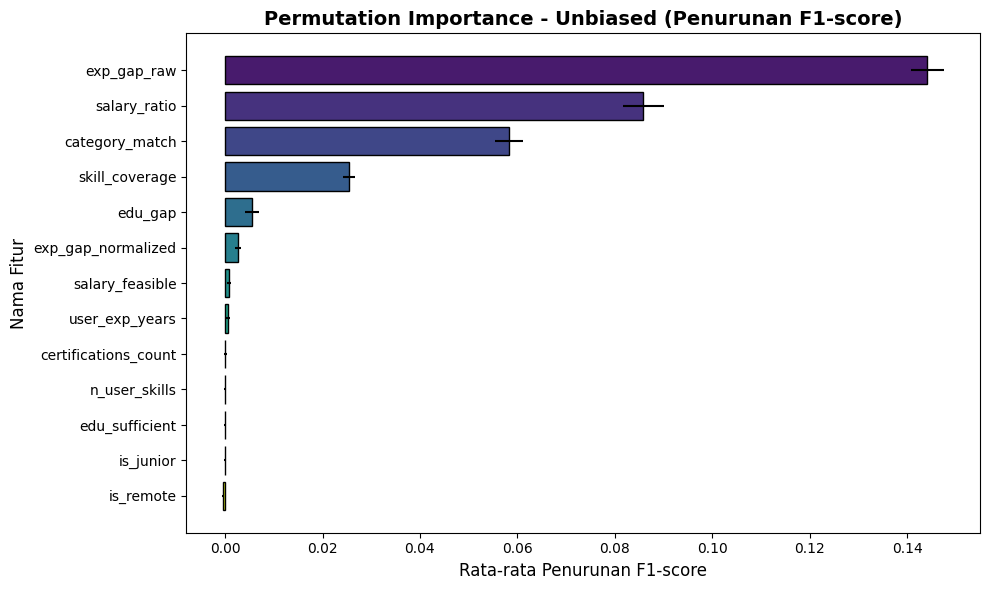

In [43]:
from sklearn.inspection import permutation_importance
# 1. Hitung Permutation Importance pada Validation Set menggunakan F1-Score sebagai metrik
result = permutation_importance(
    xgb_model, X_val, y_val, 
    n_repeats=10, 
    random_state=42, 
    scoring='f1'
)
# 2. Masukkan ke dalam DataFrame dan urutkan
perm_importances = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)
# 3. Plot hasilnya dengan plt.barh untuk menghindari bug xerr di Seaborn
plt.figure(figsize=(10, 6))
plt.barh(
    perm_importances['feature'], 
    perm_importances['importance_mean'], 
    xerr=perm_importances['importance_std'], 
    color=sns.color_palette('viridis', len(perm_importances)),
    edgecolor='black'
)
plt.gca().invert_yaxis() # Supaya fitur paling penting tetap berada di paling atas
plt.title("Permutation Importance - Unbiased (Penurunan F1-score)", fontsize=14, fontweight='bold')
plt.xlabel("Rata-rata Penurunan F1-score", fontsize=12)
plt.ylabel("Nama Fitur", fontsize=12)
plt.tight_layout()
plt.show()

### Visualisasi Confusion Matrix

Confusion matrix untuk ketiga model secara berdampingan:

**Interpretasi:**
- **True Positive (TP, kiri atas)** — model benar memprediksi cocok
- **False Positive (FP, kanan atas)** — model salah merekomendasikan (over-recommend)
- **False Negative (FN, kiri bawah)** — model melewatkan kandidat yang cocok (missed opportunity)
- **True Negative (TN, kanan bawah)** — model benar menolak yang tidak cocok

Idealnya FP dan FN seminimal mungkin. Dalam konteks rekomendasi pekerjaan,
FN lebih berbahaya (kehilangan kandidat potensial) dibanding FP (user bisa filter manual).

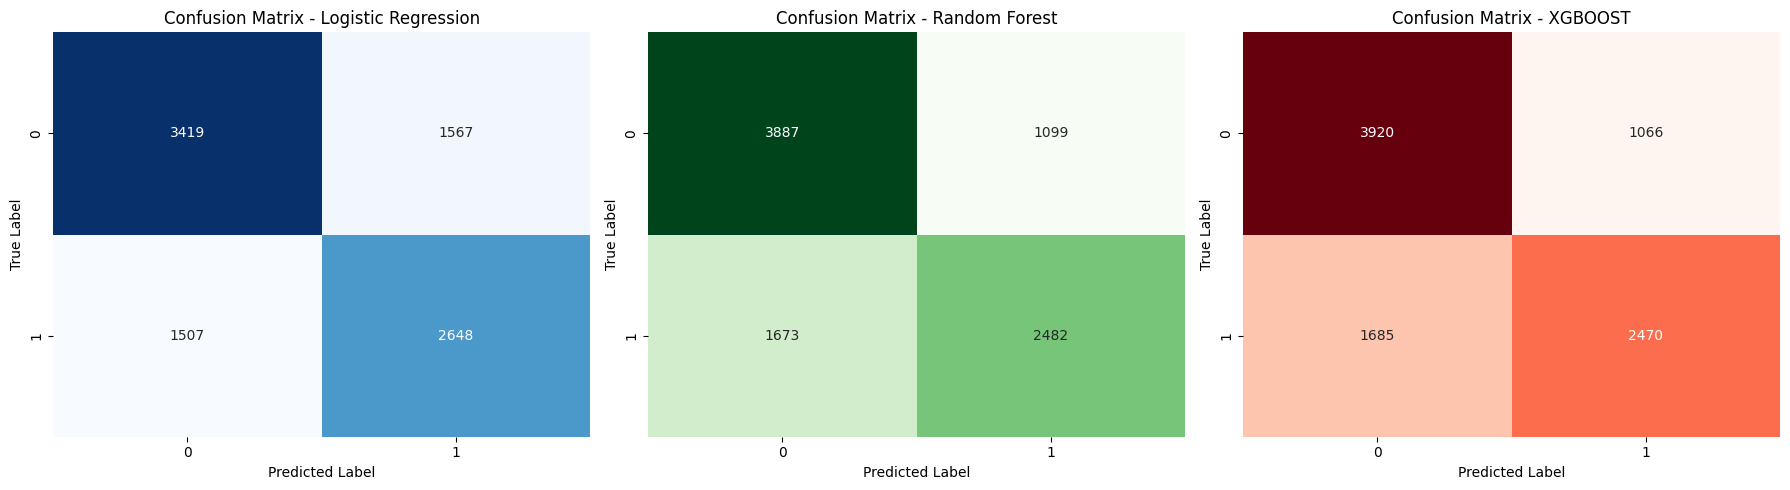

In [44]:
# 4. Plot Confusion Matrix secara Berdampingan
plt.figure(figsize=(18, 5))
# Subplot Confusion Matrix Logistic Regression
plt.subplot(1, 3, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
# Subplot Confusion Matrix Random Forest
plt.subplot(1, 3, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Subplot Confusion Matrix XGBOOST
plt.subplot(1,3,3)
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title("Confusion Matrix - XGBOOST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


---
# 5. Learning Rate & Learning Curve Analysis

Menganalisis pengaruh **learning rate** terhadap konvergensi model XGBoost dan mengevaluasi performa menggunakan ROC & Precision-Recall curves.

### Import Tambahan
Memuat SGDClassifier (untuk learning curve) dan accuracy_score.

In [45]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import learning_curve

### Learning Rate

### Eksperimen Learning Rate XGBoost

Membandingkan 4 nilai **learning rate (shrinkage)** pada XGBoost:
- 0.1 (default), 0.01, 0.001, 0.0001

**Parameter tetap:** 60 estimators (boosting rounds), eval_metric='error'

**Tujuan:** Menemukan learning rate optimal yang:
- Memberikan konvergensi cepat (sedikit pohon)
- Tidak overfitting (validation accuracy stabil)
- Akurasi final tinggi

Kurva menunjukkan akumulasi akurasi validasi seiring bertambahnya jumlah pohon.

d:\tugas-kuliah\SEMESTER 6\PROSUS DS\project-akhir\backend\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [03:44:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\tugas-kuliah\SEMESTER 6\PROSUS DS\project-akhir\backend\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [03:44:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\tugas-kuliah\SEMESTER 6\PROSUS DS\project-akhir\backend\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [03:44:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\tugas-kuliah\SEMESTER 6\PROSUS DS\project-akhir\backend\venv\lib\site-packages\xgboost\training.py:200: UserW

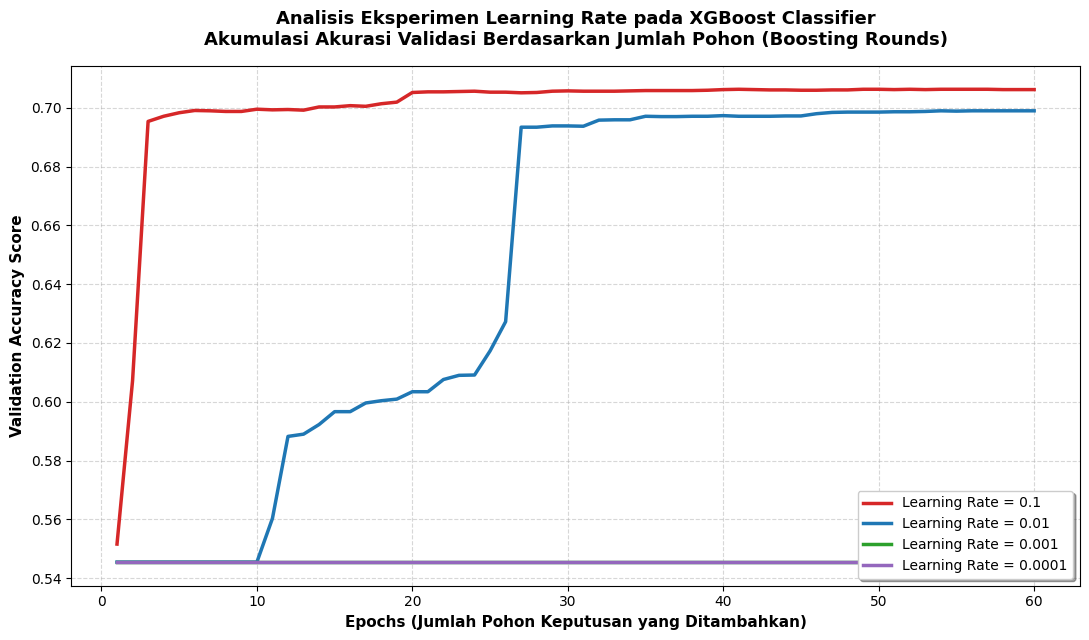

In [46]:
# Definisikan variasi Learning Rate (shrinkage) yang akan diuji
learning_rates = [0.1, 0.01, 0.001, 0.0001]
colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd'] 
epochs = 60
history = {lr: [] for lr in learning_rates}
# Proses simulasi iterasi per epoch (boosting round)
for lr in learning_rates:
    xgb_model = XGBClassifier(
        n_estimators=epochs,
        learning_rate=lr,
        random_state=42,
        eval_metric='error',  
        use_label_encoder=False
    )
    
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    evals = xgb_model.evals_result()
    
    history[lr] = [1.0 - err for err in evals['validation_0']['error']]
# ==============================================================================
# VISUALISASI PERBANDINGAN PROSES BELAJAR MODEL
# ==============================================================================
plt.figure(figsize=(11, 6.5))
for lr, color in zip(learning_rates, colors):
    plt.plot(
        range(1, epochs + 1), history[lr], 
        label=f'Learning Rate = {lr}', 
        color=color, linewidth=2.5
    )
# Estetika Grafik Premium
plt.title("Analisis Eksperimen Learning Rate pada XGBoost Classifier\nAkumulasi Akurasi Validasi Berdasarkan Jumlah Pohon (Boosting Rounds)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Epochs (Jumlah Pohon Keputusan yang Ditambahkan)", fontsize=11, fontweight='bold')
plt.ylabel("Validation Accuracy Score", fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right", frameon=True, shadow=True, fontsize=10)
plt.tight_layout()
plt.show()

### ROC

### Import ROC & PR Metrics
Memuat fungsi untuk ROC curve, AUC, Precision-Recall curve, dan Average Precision.

In [47]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

### ROC Curve & Precision-Recall Curve

Dua kurva penting untuk evaluasi model klasifikasi biner:

**1. ROC Curve (Receiver Operating Characteristic)**
- Sumbu X: False Positive Rate (1 - Specificity)
- Sumbu Y: True Positive Rate (Sensitivity/Recall)
- **AUC (Area Under Curve)** — semakin mendekati 1, semakin baik model membedakan kelas
- Kurva diagonal = random classifier (AUC=0.5)

**2. Precision-Recall Curve**
- Lebih informatif untuk dataset dengan class imbalance
- Sumbu X: Recall (TPR)
- Sumbu Y: Precision (Positive Predictive Value)
- **AP (Average Precision)** — ringkasan performa di berbagai threshold

Ketiga model dibandingkan dalam satu plot untuk memudahkan perbandingan visual.

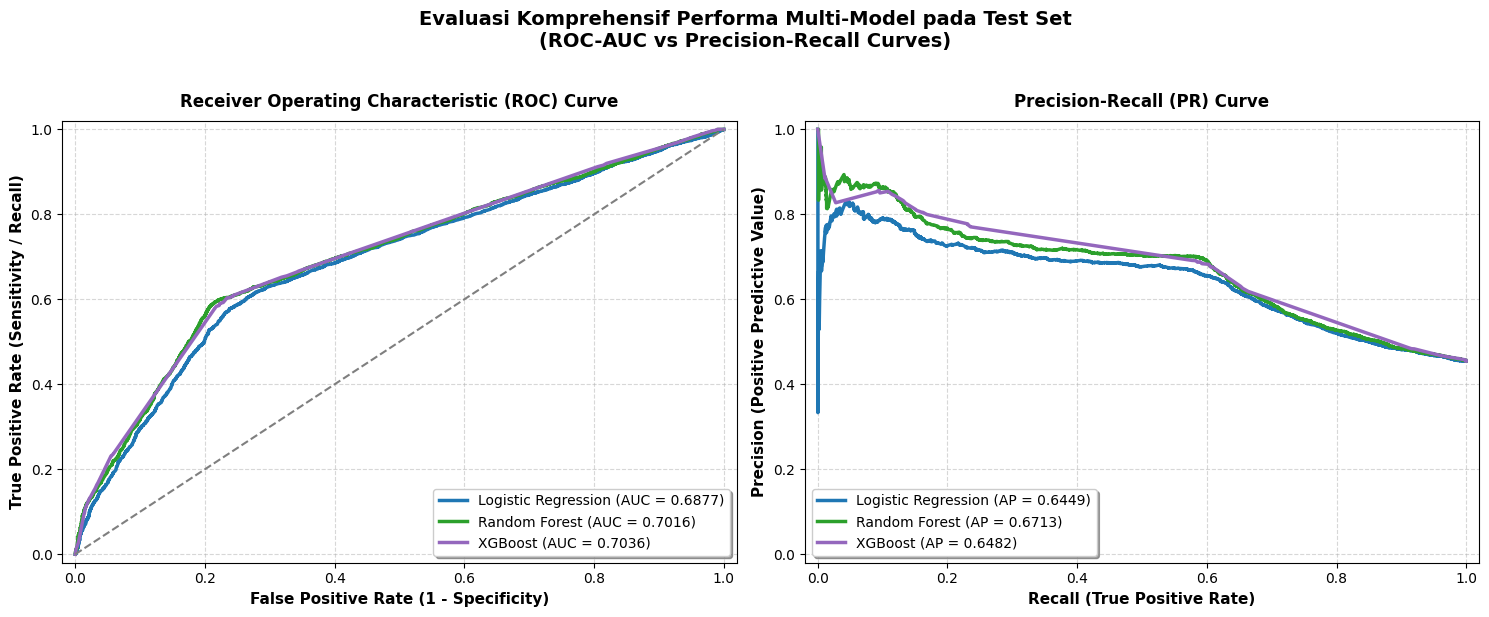

In [48]:
# 1. Hitung probabilitas prediksi (untuk kelas positif yaitu 1) pada data Testing
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]  

# 2. Hitung metrik ROC-AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb) 
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)                
# 3. Hitung metrik Precision-Recall (Average Precision)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb) 
ap_xgb = average_precision_score(y_test, y_prob_xgb)                      
# ==============================================================================
# 4. VISUALISASI SECARA BERDAMPINGAN (PREMIUM AESTHETICS)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# --- Subplot 1: ROC Curve (Receiver Operating Characteristic) ---
ax1.plot(fpr_lr, tpr_lr, color='#1f77b4', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')
ax1.plot(fpr_rf, tpr_rf, color='#2ca02c', lw=2.5, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
ax1.plot(fpr_xgb, tpr_xgb, color='#9467bd', lw=2.5, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})') # Tambahan XGBoost (Warna Ungu)
ax1.plot([0, 1], [0, 1], color='#7f7f7f', linestyle='--', lw=1.5)
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
ax1.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11, fontweight='bold')
ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold', pad=10)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower right', frameon=True, shadow=True)
# --- Subplot 2: Precision-Recall Curve (Penting untuk kelas yang tidak seimbang!) ---
ax2.plot(recall_lr, precision_lr, color='#1f77b4', lw=2.5, label=f'Logistic Regression (AP = {ap_lr:.4f})')
ax2.plot(recall_rf, precision_rf, color='#2ca02c', lw=2.5, label=f'Random Forest (AP = {ap_rf:.4f})')
ax2.plot(recall_xgb, precision_xgb, color='#9467bd', lw=2.5, label=f'XGBoost (AP = {ap_xgb:.4f})') # Tambahan XGBoost (Warna Ungu)
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.02])
ax2.set_xlabel('Recall (True Positive Rate)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Precision (Positive Predictive Value)', fontsize=11, fontweight='bold')
ax2.set_title('Precision-Recall (PR) Curve', fontsize=12, fontweight='bold', pad=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower left', frameon=True, shadow=True)
# --- Dekorasi Final ---
plt.suptitle('Evaluasi Komprehensif Performa Multi-Model pada Test Set\n(ROC-AUC vs Precision-Recall Curves)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Model Export

### Import Pickle
Memuat library pickle untuk serialisasi model Python.

In [49]:
import pickle

### Menyimpan Model ke File .pkl

Menyimpan ketiga model terbaik (best_estimator_ dari GridSearchCV) ke file pickle (.pkl):

| File | Ukuran (est.) | Digunakan di |
|---|---|---|
| `logistic_regression.pkl` | ~2 KB | Baseline prediction |
| `random_forest.pkl` | ~500 KB | Ensemble prediction |
| `xgboost.pkl` | ~200 KB | **Model utama** matcher_service.py |

Model XGBoost digunakan sebagai model utama di `backend/services/matcher_service.py`
karena memberikan accuracy & precision terbaik pada test set.

**Catatan:** Model disimpan ke direktori `backend/models/` agar mudah dimuat oleh pipeline.
Jangan commit file .pkl ke Git karena ukurannya besar.

In [50]:
model_path_lr = "logistic_regression.pkl"
model_path_rf = "random_forest.pkl"
model_path_xgb = "xgboost.pkl"
with open(model_path_lr, "wb") as f:
    pickle.dump(lr_model, f)
print(f"\n🎉 Model Logistic Regression berhasil disimpan ke: {os.path.abspath(model_path_lr)}")
with open(model_path_rf, "wb") as f:
    pickle.dump(rf_model, f)
print(f"\n🎉 Model Random Forest berhasil disimpan ke: {os.path.abspath(model_path_rf)}")
with open(model_path_xgb, "wb") as f:
    pickle.dump(xgb_model,f)
print(f"🎉 Model XGBoost berhasil disimpan ke: {os.path.abspath(model_path_xgb)}")



🎉 Model Logistic Regression berhasil disimpan ke: d:\tugas-kuliah\SEMESTER 6\PROSUS DS\project-akhir\backend\models\logistic_regression.pkl

🎉 Model Random Forest berhasil disimpan ke: d:\tugas-kuliah\SEMESTER 6\PROSUS DS\project-akhir\backend\models\random_forest.pkl
🎉 Model XGBoost berhasil disimpan ke: d:\tugas-kuliah\SEMESTER 6\PROSUS DS\project-akhir\backend\models\xgboost.pkl
